# **Environmental SetUp**

In [1]:
!pip install -q git+https://github.com/tensorflow/examples.git

You should consider upgrading via the '/mnt/home/tkomolkhetruck/unet_tf_env/bin/python3 -m pip install --upgrade pip' command.


In [2]:
# Main libs
import cv2
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Data Imports
import os
import pandas as pd
import albumentations as A
from glob import glob
import tensorflow.data as tfd
from tqdm import tqdm

# Data Visualization
from PIL import Image
import plotly.express as px
import matplotlib.pyplot as plt
from IPython.display import Image as GIF

# Unet Architecture
from tensorflow.keras import layers
from tensorflow_examples.models.pix2pix import pix2pix

2026-04-28 16:12:27.920251: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 16:12:29.260553: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-28 16:12:55.256063: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [13]:
# Data Configs
BATCH_SIZE = 16
IMAGE_SIZE = (512, 512)
DATA_DIR = "/mnt/home/tkomolkhetruck/sam3_irrigation_canals/sam3/train/data/road"

# Reproducibility
SEED = 42
BATCH_SIZE = 32
VALIDATION_SIZE = int(1e3)
AUTOTUNE = tfd.AUTOTUNE
tf.random.set_seed(SEED)

# **Loading Dataset**

In [14]:
def load_images_to_array(image_paths, image_size):
    num_images = len(image_paths)
    # Initialize an empty array for images
    images = np.zeros((num_images, *image_size, 3), dtype=np.float32)  # Assuming RGB images
    
    for i, path in tqdm(enumerate(image_paths), desc="Loading"):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)
        img = img / 255.0
        images[i] = img
    
    return images

def load_masks_to_array(mask_paths, image_size):
    num_masks = len(mask_paths)
    # Initialize an empty array for masks
    masks = np.zeros((num_masks, *image_size, 1), dtype=np.float32)  # Assuming grayscale masks
    
    for i, path in tqdm(enumerate(mask_paths), desc="Loading"):
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, image_size)
        mask = mask / 255.0
        masks[i] = np.expand_dims(mask, axis=-1)
    
    return masks

def show_image(image, title=None, alpha=1):
    """
    Display the given image with an optional title.

    Args:
        image (tf.Tensor): The image tensor to be displayed.
        title (str, optional): The title of the image. Defaults to None.
        alpha (float, optional): The alpha transparency value of the image. Defaults to 1.
    """
    plt.imshow(image, alpha=alpha)
    plt.title(title)
    plt.axis('off')
    
def show_image_masks(dataset, n_rows=5, n_cols=3, figsize=(10, 15)):
    """
    Display a grid of images and their corresponding masks from the given dataset.

    Args:
        dataset (tf.data.Dataset): The dataset containing pairs of images and masks.
        n_rows (int, optional): Number of rows in the grid. Defaults to 5.
        n_cols (int, optional): Number of columns in the grid. Defaults to 3.
        figsize (tuple, optional): Figure size of the plot. Defaults to (10, 15).
    """
    images, masks = next(iter(dataset.take(1)))

    plt.figure(figsize=figsize)
    for i in range(1, (n_rows * n_cols) + 1, n_cols):

        plt.subplot(n_rows, n_cols, i)
        show_image(images[i], title="Aerial Imagery")

        plt.subplot(n_rows, n_cols, i + 1)
        show_image(masks[i], title="Image Mask")

        plt.subplot(n_rows, n_cols, i + 2)
        show_image(images[i])
        show_image(masks[i], alpha=0.5, title="Overlapping")

    plt.show()


In [15]:
metadata = pd.read_csv("/mnt/home/tkomolkhetruck/sam3_irrigation_canals/sam3/train/data/road/metadata.csv")

train_metadata = metadata[metadata['split'] == "train"][['tiff_image_path', 'tif_label_path']]
valid_metadata = metadata[metadata['split'] == "val"][['tiff_image_path', 'tif_label_path']]
test_metadata = metadata[metadata['split'] == "test"][['tiff_image_path', 'tif_label_path']]

train_metadata['tiff_image_path'] = train_metadata['tiff_image_path'].apply(lambda path: DATA_DIR + path)
train_metadata['tif_label_path'] = train_metadata['tif_label_path'].apply(lambda path: DATA_DIR + path)

valid_metadata['tiff_image_path'] = valid_metadata['tiff_image_path'].apply(lambda path: DATA_DIR + path)
valid_metadata['tif_label_path'] = valid_metadata['tif_label_path'].apply(lambda path: DATA_DIR + path)

test_metadata['tiff_image_path'] = test_metadata['tiff_image_path'].apply(lambda path: DATA_DIR + path)
test_metadata['tif_label_path'] = test_metadata['tif_label_path'].apply(lambda path: DATA_DIR + path)

In [16]:
# Convert DataFrames to lists of paths
x_train_paths = train_metadata['tiff_image_path'].tolist()
y_train_paths = train_metadata['tif_label_path'].tolist()

x_valid_paths = valid_metadata['tiff_image_path'].tolist()
y_valid_paths = valid_metadata['tif_label_path'].tolist()

x_test_paths = test_metadata['tiff_image_path'].tolist()
y_test_paths = test_metadata['tif_label_path'].tolist()

# Load data into NumPy arrays
x_train_array = load_images_to_array(x_train_paths, IMAGE_SIZE)
y_train_array = load_masks_to_array(y_train_paths, IMAGE_SIZE)

x_valid_array = load_images_to_array(x_valid_paths, IMAGE_SIZE)
y_valid_array = load_masks_to_array(y_valid_paths, IMAGE_SIZE)

x_test_array = load_images_to_array(x_test_paths, IMAGE_SIZE)
y_test_array = load_masks_to_array(y_test_paths, IMAGE_SIZE)

Loading: 0it [00:00, ?it/s][ WARN:0@3226.922] global loadsave.cpp:278 findDecoder imread_('/mnt/home/tkomolkhetruck/sam3_irrigation_canals/sam3/train/data/roadtiff/train/10078660_15.tiff'): can't open/read file: check file path/integrity
Loading: 0it [00:00, ?it/s]


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [8]:
def create_dataset(images, masks, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((images, masks))
    dataset = dataset.shuffle(buffer_size=len(images))  
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

# Convert NumPy arrays to TensorFlow datasets
train_ds = create_dataset(x_train_array, y_train_array, BATCH_SIZE)
valid_ds = create_dataset(x_valid_array, y_valid_array, BATCH_SIZE)
test_ds = create_dataset(x_test_array, y_test_array, BATCH_SIZE)

NameError: name 'x_train_array' is not defined

In [ ]:
show_image_masks(train_ds)

In [ ]:
train_samples = tfd.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
valid_samples = tfd.experimental.cardinality(valid_ds).numpy() * BATCH_SIZE

print("Training   Samples:", train_samples)
print("Validation Samples:", valid_samples)

# **UNet Model**

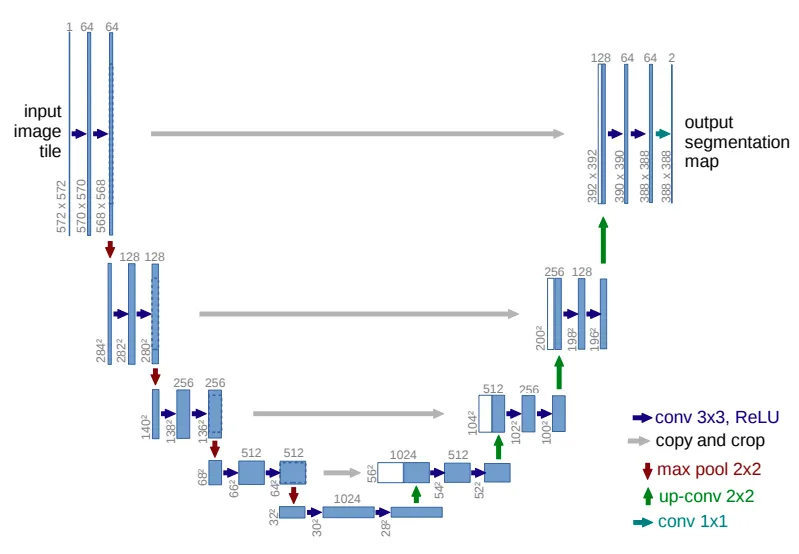

The U-Net architecture is a convolutional neural network (CNN) designed for semantic segmentation tasks, particularly in biomedical image analysis, but it has found applications in various other domains such as satellite imagery, self-driving cars, and more. The architecture was introduced by Olaf Ronneberger, Philipp Fischer, and Thomas Brox in their 2015 paper titled "U-Net: Convolutional Networks for Biomedical Image Segmentation."

### Overview:
The U-Net architecture derives its name from its characteristic U-shape structure. It consists of a contracting path (left side of the U) that captures context and a symmetric expanding path (right side of the U) that enables precise localization. At each level of the contracting path, the feature maps are downsampled to capture context efficiently, while the expanding path upsamples the feature maps to generate segmentation masks. Skip connections connect corresponding layers in the contracting and expanding paths to facilitate precise localization.

### Architecture:
1. **Contracting Path (Encoder):**
   - The contracting path resembles a typical convolutional neural network for image classification. It consists of multiple convolutional blocks, each comprising two consecutive convolutional layers followed by a rectified linear unit (ReLU) activation function and optional max pooling for downsampling.
   - As the feature maps pass through each convolutional block, the spatial dimensions decrease while the number of channels (feature maps) increases. This allows the network to capture hierarchical features at multiple scales.
   - After each convolutional block, the current feature map is stored in a list to be used later during the expanding path.

2. **Expanding Path (Decoder):**
   - The expanding path is composed of multiple upsampling blocks, each consisting of an upsampling operation followed by a convolutional block.
   - The upsampling operation increases the spatial dimensions of the feature maps, typically using transposed convolution (also known as deconvolution) or nearest-neighbor interpolation followed by convolution. This step helps recover spatial information lost during downsampling in the contracting path.
   - Each convolutional block in the expanding path consists of two consecutive convolutional layers followed by ReLU activation. Before each convolutional layer, the feature maps from the corresponding level in the contracting path (skip connection) are concatenated with the upsampled feature maps. This facilitates precise localization by combining high-resolution features with contextual information.
   
3. **Skip Connections:**
   - Skip connections are a key component of the U-Net architecture, facilitating information flow between the contracting and expanding paths.
   - At each level of the contracting path, the feature maps are copied and concatenated with the corresponding level in the expanding path. This allows the network to recover fine-grained details lost during downsampling.
   - Skip connections enable U-Net to combine low-level details from early layers with high-level semantic information from later layers, leading to accurate segmentation results.

### Output:
The final output of the U-Net architecture is a segmentation mask with the same spatial dimensions as the input image, where each pixel is classified into different classes or categories based on the semantic segmentation task.

### Applications:
- Biomedical image segmentation: U-Net has been widely used for segmenting biomedical images, including cell segmentation, tissue segmentation, and medical image segmentation tasks.
- Satellite and aerial image segmentation: U-Net can segment objects of interest in satellite and aerial images, such as buildings, roads, and vegetation.
- Semantic segmentation in autonomous driving: U-Net can segment different objects in scenes captured by vehicle-mounted cameras, facilitating tasks like lane detection, pedestrian detection, and obstacle avoidance.

### Advantages:
- High performance: U-Net achieves state-of-the-art results in many semantic segmentation tasks, thanks to its effective architecture and skip connections.
- Data efficiency: U-Net requires relatively fewer annotated training samples compared to other architectures, making it suitable for scenarios with limited labeled data.
- Flexibility: U-Net's modular architecture allows easy adaptation to different input sizes, number of classes, and application domains.

### Limitations:
- Boundary artifacts: U-Net may produce artifacts at object boundaries due to the combination of downsampling and upsampling operations. Techniques like padding and post-processing can mitigate this issue.
- Computationally intensive: U-Net's expansive architecture and skip connections can be computationally expensive, particularly for high-resolution images and deep networks. Efficient variants like U-Net++ and Attention U-Net address this concern.

In summary, the U-Net architecture is a powerful and versatile deep learning model for semantic segmentation, with widespread applications across various fields, including biomedical imaging, remote sensing, and autonomous driving. Its ability to capture context and precise localization makes it a popular choice for many segmentation tasks.

---
The model being used here is a modified [U-Net](https://arxiv.org/abs/1505.04597). A U-Net consists of an encoder (downsampler) and decoder (upsampler). To learn robust features and reduce the number of trainable parameters, use a pretrained model—[MobileNetV2](https://arxiv.org/abs/1801.04381)—as the encoder. For the decoder, you will use the upsample block, which is already implemented in the [pix2pix](https://github.com/tensorflow/examples/blob/master/tensorflow_examples/models/pix2pix/pix2pix.py) example in the TensorFlow Examples repo.

In [ ]:
# Loading the base model
base_model = keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False
)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]

base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Initialize the encoder model (Downsampling block)
encoder = keras.Model(
    inputs=base_model.input,
    outputs=base_model_outputs,
    name="Encoder"
)

# Freeze the model weights
encoder.trainable = False

In [ ]:
# Decoder (Up-sampling block)
decoder = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

To further improve the model architecture, it's essential to incorporate skip connections, which are currently absent. Skip connections play a crucial role in the U-Net architecture by facilitating the flow of information between the contracting and expanding paths. These connections enable the model to combine high-resolution details with contextual information, enhancing the accuracy of segmentation results. By integrating skip connections, we ensure that the model effectively captures both local and global features, leading to more precise segmentation outputs.

In [ ]:
def CustomUNet(encoder_block, decoder_block, output_channels=1, **kwargs):
    """
    Custom U-Net model for semantic segmentation.

    Args:
        encoder_block (tf.keras.Model): Encoder block of the U-Net model.
        decoder_block (list): List of decoder blocks for the U-Net model.
        output_channels (int, optional): Number of output channels/classes. Defaults to 3.
        **kwargs: Additional keyword arguments passed to the base class constructor.

    Returns:
        tf.keras.Model: U-Net model for semantic segmentation.
    """
    # Input layer
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="ImageInput")

    # Pass it through the encoder
    encodings = encoder_block(inputs)
    skips = reversed(encodings[:-1])        
    encoding = encodings[-1]

    # Upsampling and Skip connections
    for index, (up, skip) in enumerate(zip(decoder_block, skips)):
        encoding = up(encoding)
        encoding = layers.Concatenate(name=f"ConCat-{index+1}")([encoding, skip])

    # The Output layer
    mask_out = layers.Conv2DTranspose(
        filters=1,
        kernel_size=3,
        strides=2,
        padding="same",
    )(encoding)
    
    mask_out = layers.Conv2D(
        filters=1,
        kernel_size=1,
        padding="same",
        activation='sigmoid',
        name="MaskOut"
    )(mask_out)

    # Define the model
    model = keras.Model(inputs, mask_out, **kwargs)
    
    return model

In [ ]:
# Initialize model
model = CustomUNet(encoder, decoder, name="CustomUNet")

# Model architecture
model.summary()

# **Model Training**

Let's craft a custom callback to visualize the model's performance after each epoch, providing us with valuable insights into its training progress and effectiveness.

In [ ]:
def show_pred_masks(dataset, model, n_rows=5, n_cols=6, figsize=(15, 15), savepath=None):
    """
    Display a grid of images, their true masks, and predicted masks from the given dataset using the provided model.

    Args:
        dataset (tf.data.Dataset): The dataset containing pairs of images and masks.
        model (tf.keras.Model): The trained model for predicting masks.
        n_rows (int, optional): Number of rows in the grid. Defaults to 5.
        n_cols (int, optional): Number of columns in the grid. Defaults to 3.
        figsize (tuple, optional): Figure size of the plot. Defaults to (10, 15).
        savepath (str, optional): Path to save the figure. Defaults to None.
    """
    images, masks = next(iter(dataset.take(1)))
    pred_masks = model.predict(images)

    plt.figure(figsize=figsize)
    for i in range(1, (n_rows * n_cols) + 1, n_cols):
        
        plt.subplot(n_rows, n_cols, i)
        show_image(images[i], title="Aerial Imagery")

        plt.subplot(n_rows, n_cols, i + 1)
        show_image(masks[i], title="True Image Mask")

        plt.subplot(n_rows, n_cols, i + 2)
        show_image(pred_masks[i], title="Predicted Image Mask")
        
        plt.subplot(n_rows, n_cols, i + 3)
        show_image(tf.cast(pred_masks[i]>=0.5, tf.float32), title="Processed Mask(0.5)")
        
        plt.subplot(n_rows, n_cols, i + 4)
        show_image(tf.cast(pred_masks[i]>=0.7, tf.float32), title="Processed Mask(0.7)")
        
        plt.subplot(n_rows, n_cols, i + 5)
        show_image(images[i])
        show_image(pred_masks[i], alpha=0.5, title="Overlapping")
        
        
    if savepath is not None:
        plt.savefig(savepath)
        
    plt.show()


class ShowImageMasksCallback(keras.callbacks.Callback):
    """
    Callback to visualize the model's predicted masks on the validation dataset at the end of each epoch.

    Args:
        dataset (tf.data.Dataset): The validation dataset containing pairs of images and masks.
    """
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset

    def on_epoch_end(self, epoch, logs=None):
        """
        Display the predicted masks on the validation dataset at the end of each epoch.

        Args:
            epoch (int): Current epoch number.
            logs (dict): Dictionary containing training metrics for the current epoch.
        """
        show_pred_masks(dataset=self.dataset, n_rows=3, model=self.model, savepath=f"ModelPred_Epoch_{epoch}.png", figsize=(15, 10))

In [ ]:
# Model Compilation
model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

# Training Configs
steps_per_epoch = train_samples//BATCH_SIZE

# Model Training
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_ds,
    epochs=50,
    callbacks=[ShowImageMasksCallback(valid_ds)]
)

# **Model Training Generations**

Although mathematical measures are commonly used to compare model performances, I often prefer to rely on visual inspection to assess the model's performance. Observing the generated outputs during the training phase provides valuable insights into how well the model is learning.

In [ ]:
training_gens = sorted(glob("/kaggle/working/*.png"), key=lambda path: int(path.split('.')[0].split('_')[-1]))

frames = []
for i in training_gens:
    new_frame = Image.open(i)
    frames.append(new_frame)

# Save into a GIF file that loops forever
frames[0].save('traiing_gens.gif', format='GIF',
               append_images=frames[1:],
               save_all=True,
               duration=300, loop=0)

GIF("/kaggle/working/traiing_gens.gif")

If you closely observe the model's evolution over time, you'll notice its increasing ability to generalize and identify green regions, despite imperfect annotations. The model's focus on green areas, rather than strictly adhering to the provided mask, is a positive development. This adaptability is evident even when comparing it to a model trained from scratch, indicating that the annotations may not be ideal. By prioritizing the detection of green regions, the model demonstrates its understanding of the task at hand, reflecting its evolving performance across numerous images.

# **Model Prediction**

In [ ]:
show_pred_masks(valid_ds.shuffle(500), model=model, n_rows=3)
show_pred_masks(valid_ds.shuffle(500), model=model, n_rows=3)
show_pred_masks(valid_ds.shuffle(500), model=model, n_rows=3)

When evaluating the model's performance, it's tempting to focus solely on the discrepancies between the predicted and post-processed masks, highlighting potential shortcomings in the annotations. However, I urge you to consider the quality of overlap between the two masks. This overlap indicates the model's proficiency in identifying forested areas within satellite images, which is the primary objective. Despite any imperfections, the model's ability to discern forested regions is evident in the clean overlap. Moving forward, incorporating post-processing steps, such as smoothing functions, can enhance the model's predictions by refining boundary delineations. Additionally, the model's performance in thresholding is noteworthy, although there's room for further improvement. Overall, while acknowledging areas for enhancement, it's essential to recognize the model's successful identification of forested areas based on the quality of overlap.

In [ ]:
figsize = (20, 20)
n_rows, n_cols = 4, 5

images, masks = next(iter(train_ds.shuffle(1000).take(1)))
pred_masks = model.predict(images)

plt.figure(figsize=figsize)
for i in range(1, (n_rows * n_cols) + 1, n_cols):

    plt.subplot(n_rows, n_cols, i)
    show_image(images[i], title="Aerial Imagery")
    
    plt.subplot(n_rows, n_cols, i + 1)
    show_image(images[i])
    show_image(masks[i], alpha=0.6, title="True Mask")
    
    plt.subplot(n_rows, n_cols, i + 2)
    show_image(images[i])
    show_image(pred_masks[i]>=0.5, alpha=0.6, title="Overlapping (0.5)")
    
    plt.subplot(n_rows, n_cols, i + 3)
    show_image(images[i])
    show_image(pred_masks[i]>=0.7, alpha=0.6, title="Overlapping (0.7)")
    
    plt.subplot(n_rows, n_cols, i + 4)
    show_image(images[i])
    show_image(pred_masks[i]>=0.9, alpha=0.6, title="Overlapping (0.9)")

plt.show()

To arrive at a conclusion regarding whether the model or the data is at fault, it's evident that both aspects contribute to the challenges faced. The data annotations exhibit imperfections, as evidenced by instances where images lack corresponding masks despite the presence of greenery. This discrepancy arises due to the ambiguity in distinguishing between non-green regions and forested areas, particularly in cases where the delineation is unclear.

Examining the model's performance provides further insights. When evaluating model generations using different thresholds (e.g., 0.5, 0.7, and 0.9), results vary. At a threshold of 0.5, the model appears to perform admirably, with satisfactory outcomes. However, as the threshold increases to 0.7, performance becomes more localized and specific to certain regions. Finally, at a threshold of 0.9, it becomes apparent that the model's generations lack confidence, particularly in accurately identifying forest regions.

In summary, both the data annotations and the model exhibit areas for improvement. Addressing these shortcomings through refined annotations and model enhancements will lead to more accurate and reliable results, ultimately culminating in improved performance.

---
**DeepNets**

# **Save & Load Model**

In [ ]:
# Save the entire model to a file
model.save('unet_satimg_to_roadmap_model.keras')

In [ ]:
# Load the model from the .keras file
loaded_model = tf.keras.models.load_model(
    'unet_satimg_to_roadmap_model.keras', 
    custom_objects={'CustomUNet': CustomUNet}
)

# Verify that the model has been loaded correctly by printing its summary
loaded_model.summary()

In [ ]:
figsize = (20, 20)
n_rows, n_cols = 4, 5

images, masks = next(iter(train_ds.shuffle(1000).take(1)))
pred_masks = loaded_model.predict(images)

plt.figure(figsize=figsize)
for i in range(1, (n_rows * n_cols) + 1, n_cols):

    plt.subplot(n_rows, n_cols, i)
    show_image(images[i], title="Aerial Imagery")
    
    plt.subplot(n_rows, n_cols, i + 1)
    show_image(images[i])
    show_image(masks[i], alpha=0.6, title="True Mask")
    
    plt.subplot(n_rows, n_cols, i + 2)
    show_image(images[i])
    show_image(pred_masks[i]>=0.5, alpha=0.6, title="Overlapping (0.5)")
    
    plt.subplot(n_rows, n_cols, i + 3)
    show_image(images[i])
    show_image(pred_masks[i]>=0.7, alpha=0.6, title="Overlapping (0.7)")
    
    plt.subplot(n_rows, n_cols, i + 4)
    show_image(images[i])
    show_image(pred_masks[i]>=0.9, alpha=0.6, title="Overlapping (0.9)")

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

def evaluate_segmentation_iou(model, dataset, threshold=0.5):
    total_intersection = 0
    total_union = 0
    total_correct = 0
    total_pixels = 0

    per_image_ious = []

    for images, masks in dataset:
        # Model outputs probability map, usually shape [B, H, W, 1]
        preds = model(images, training=False)

        y_true = masks.numpy()
        y_score = preds.numpy()

        # Convert masks/predictions to binary
        y_true = y_true > 0.5
        y_pred = y_score > threshold

        # Make sure shapes are compatible
        if y_true.shape != y_pred.shape:
            raise ValueError(f"Shape mismatch: y_true={y_true.shape}, y_pred={y_pred.shape}")

        # Per-image IoU
        batch_size = y_true.shape[0]
        for i in range(batch_size):
            gt = y_true[i]
            pred = y_pred[i]

            intersection = np.logical_and(pred, gt).sum()
            union = np.logical_or(pred, gt).sum()

            if union == 0:
                iou = 1.0
            else:
                iou = intersection / union

            per_image_ious.append(iou)

        # Global IoU
        total_intersection += np.logical_and(y_pred, y_true).sum()
        total_union += np.logical_or(y_pred, y_true).sum()

        # Pixel accuracy
        total_correct += (y_pred == y_true).sum()
        total_pixels += y_true.size

    mean_iou = float(np.mean(per_image_ious))
    global_iou = float(total_intersection / max(total_union, 1))
    pixel_accuracy = float(total_correct / max(total_pixels, 1))

    return {
        "mean_iou": mean_iou,
        "global_iou": global_iou,
        "pixel_accuracy": pixel_accuracy,
    }


results = evaluate_segmentation_iou(model, val_dataset, threshold=0.5)

print("Mean IoU:", results["mean_iou"])
print("Global IoU:", results["global_iou"])
print("Pixel accuracy:", results["pixel_accuracy"])